In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Union
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


class LinearRegressionModel:
    """
    A general-purpose linear regression model that supports both simple and multiple regression.
    Handles missing values and visualizes regression results.
    """

    def __init__(self, data_path: str, x_columns: Union[str, List[str]], y_column: str) -> None:
        self.data_path = data_path
        self.x_columns = [x_columns] if isinstance(x_columns, str) else x_columns
        self.y_column = y_column
        self.df = pd.DataFrame()
        self.model = LinearRegression()
        self.X_train: np.ndarray = np.array([])
        self.X_test: np.ndarray = np.array([])
        self.y_train: np.ndarray = np.array([])
        self.y_test: np.ndarray = np.array([])

    def load_and_explore_data(self) -> None:
        """Load dataset, show summary, and visualize with scatter or scatter matrix."""
        self.df = pd.read_csv(self.data_path)
        print("First 5 Rows:\n", self.df.head())
        print("\nSummary Statistics:\n", self.df.describe())
        print("\nMissing Values:\n", self.df.isnull().sum())

        if len(self.x_columns) == 1:
            x = self.df[[self.x_columns[0]]].dropna()
            y = self.df.loc[x.index, self.y_column]

            temp_model = LinearRegression()
            temp_model.fit(x, y)

            x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
            y_line = temp_model.predict(x_line)

            plt.figure(figsize=(8, 5))
            plt.scatter(x, y, color='blue', label='Data Points')
            plt.plot(x_line, y_line, color='red', label='Regression Line')
            plt.xlabel(self.x_columns[0])
            plt.ylabel(self.y_column)
            plt.title('Scatter Plot with Regression Line')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            # Scatter matrix for multiple regression
            pd.plotting.scatter_matrix(self.df[self.x_columns + [self.y_column]], figsize=(10, 6))
            plt.suptitle("Feature Scatter Matrix")
            plt.grid(True)
            plt.show()

    def prepare_data(self, test_size: float = 0.2, random_state: int = 42) -> None:
        """Handle missing values (drop rows) and split into train/test sets."""
        if self.df.isnull().values.any():
            print("⚠️ Missing values detected — dropping rows with nulls.")
            self.df.dropna(inplace=True)
            print(f"Missing values dropped. New shape: {self.df.shape}")
        else:
            print("No missing values found.")

        X = self.df[self.x_columns].values
        y = self.df[self.y_column].values
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

    def train_model(self) -> None:
        """Train the linear regression model."""
        self.model.fit(self.X_train, self.y_train)

    def evaluate_model(self) -> None:
        """Print regression evaluation metrics."""
        predictions = self.model.predict(self.X_test)
        print(f"MAE: {mean_absolute_error(self.y_test, predictions):.2f}")
        print(f"MSE: {mean_squared_error(self.y_test, predictions):.2f}")
        print(f"RMSE: {np.sqrt(mean_squared_error(self.y_test, predictions)):.2f}")
        print(f"R² Score: {r2_score(self.y_test, predictions):.2f}")

    def visualize_results(self) -> None:
        """Visualize results: regression line for simple; actual vs predicted for multiple."""
        predictions = self.model.predict(self.X_test)

        if len(self.x_columns) == 1:
            plt.figure(figsize=(8, 5))
            plt.scatter(self.X_test, self.y_test, color='blue', label='Actual Data')
            X_line = np.linspace(self.X_test.min(), self.X_test.max(), 100).reshape(-1, 1)
            y_line = self.model.predict(X_line)
            plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')
            plt.xlabel(self.x_columns[0])
            plt.ylabel(self.y_column)
            plt.title("Test Data - Regression Line and Scatter Plot")
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            plt.figure(figsize=(7, 5))
            plt.scatter(self.y_test, predictions, alpha=0.7, color='green', label='Predicted vs Actual')
            plt.plot([self.y_test.min(), self.y_test.max()],
                     [self.y_test.min(), self.y_test.max()],
                     color='red', linestyle='--', label='Perfect Prediction')
            plt.xlabel("Actual")
            plt.ylabel("Predicted")
            plt.title("Test Data - Actual vs Predicted (Multiple Linear Regression)")
            plt.legend()
            plt.grid(True)
            plt.show()


### Simple Linear Regression

First 5 Rows:
    area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000

Summary Statistics:
               area          price
count  1005.000000    1005.000000
mean   2728.221891  328780.261692
std    1307.687692  159758.985887
min     500.000000   33346.000000
25%    1583.000000  192995.000000
50%    2699.000000  326359.000000
75%    3877.000000  467028.000000
max    4999.000000  725000.000000

Missing Values:
 area     0
price    0
dtype: int64


/opt/anaconda3/envs/venv_py311/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


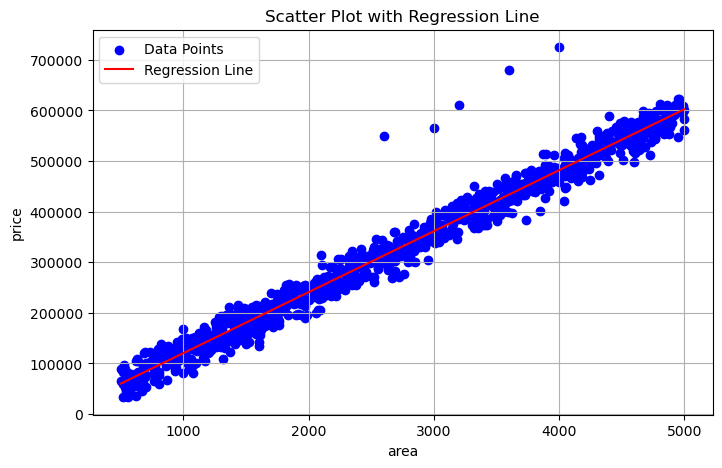

No missing values found.
MAE: 15666.65
MSE: 380758008.43
RMSE: 19513.02
R² Score: 0.99


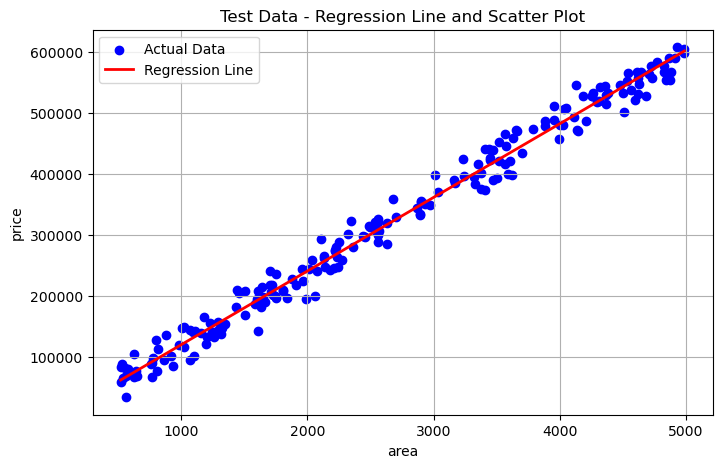

In [2]:
model = LinearRegressionModel("homeprices.csv", x_columns="area", y_column="price")
model.load_and_explore_data()
model.prepare_data()
model.train_model()
model.evaluate_model()
model.visualize_results()

### Multiple Linear Regression

First 5 Rows:
    area  bedrooms  age   price
0  1460       3.0    8  195536
1  4372       1.0   33  526139
2  3692       NaN    6  524207
3  1066       3.0   39  111925
4  4044       2.0    4  511168

Summary Statistics:
               area    bedrooms          age          price
count  1000.000000  980.000000  1000.000000    1000.000000
mean   2854.807000    3.462245    20.056000  356472.815000
std    1221.734084    1.699487    11.195723  149091.638174
min     603.000000    1.000000     1.000000   36587.000000
25%    1816.250000    2.000000    10.000000  238966.250000
50%    2871.500000    3.000000    21.000000  364508.500000
75%    3881.500000    5.000000    30.000000  477931.500000
max    4989.000000    6.000000    39.000000  694382.000000

Missing Values:
 area         0
bedrooms    20
age          0
price        0
dtype: int64


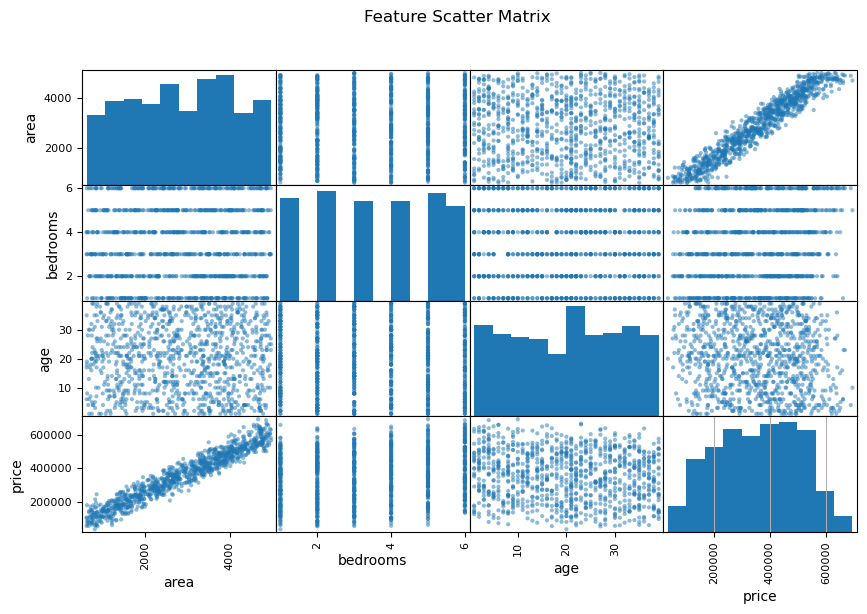

⚠️ Missing values detected — dropping rows with nulls.
Missing values dropped. New shape: (980, 4)
MAE: 25027.55
MSE: 997798405.43
RMSE: 31587.95
R² Score: 0.96


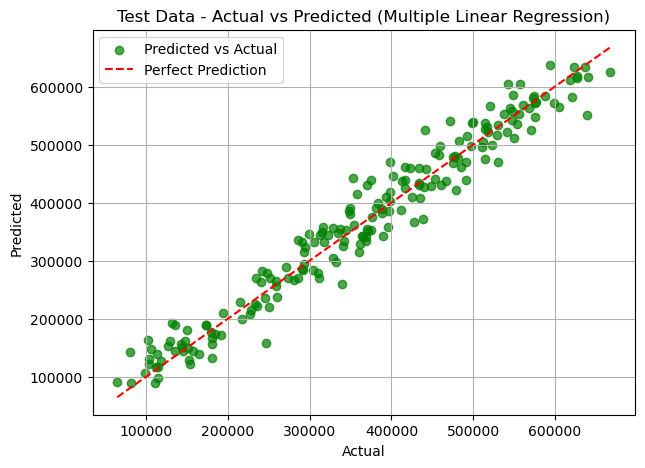

In [3]:
features = ["area", "bedrooms", "age"]
model = LinearRegressionModel("homeprices-m.csv", x_columns=features, y_column="price")
model.load_and_explore_data()
model.prepare_data()
model.train_model()
model.evaluate_model()
model.visualize_results()


### Scripts for genrating more data for homeprices.csv and homeprices-m.csv files

##### Generates data with intentional missing values for multiple linear regression (homeprices-m.csv)

In [ ]:
# Generate tailored multiple linear regression dataset with intentional missing values
def generate_custom_multiple_linear_data(n: int = 1_000, missing_rate: float = 0.02) -> pd.DataFrame:
    np.random.seed(42)
    area = np.random.randint(600, 5_000, size=n)
    bedrooms = np.random.randint(1, 7, size=n)
    age = np.random.randint(1, 40, size=n)
    
    # Price is a function of area, bedrooms, and age, with noise
    price = (115 * area + 15_000 * bedrooms - 1_200 * age +
             np.random.normal(0, 30_000, size=n))
    
    df = pd.DataFrame({
        "area": area,
        "bedrooms": bedrooms,
        "age": age,
        "price": price.astype(int)
    })

    # Inject missing values into bedrooms (e.g., 2% of data)
    missing_indices = np.random.choice(df.index, size=int(missing_rate * n), replace=False)
    df.loc[missing_indices, 'bedrooms'] = np.nan

    return df

# Create and save the dataset
custom_multi_df = generate_custom_multiple_linear_data(n=1_000, missing_rate=0.02)
custom_multi_path = "homeprices-m.csv"
custom_multi_df.to_csv(custom_multi_path, index=False)

custom_multi_path


##### Generates data with no missing values for both datasets

In [ ]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# ----- 1. Generate data for Simple Linear Regression (area, price) -----
def generate_simple_linear_data(n=10_000):
    area = np.random.randint(500, 5_000, n)
    price = 120 * area + np.random.normal(0, 20_000, n)  # Add noise
    return pd.DataFrame({'area': area, 'price': price.astype(int)})

# Add to original 5 rows
simple_base = pd.DataFrame({
    'area': [2_600, 3_000, 3_200, 3_600, 4_000],
    'price': [550_000, 565_000, 610_000, 680_000, 725_000]
})
simple_data = pd.concat([simple_base, generate_simple_linear_data()], ignore_index=True)

# ----- 2. Generate data for Multiple Linear Regression (area, bedrooms, age, price) -----
def generate_multiple_linear_data(n=10_000):
    area = np.random.randint(500, 5_000, n)
    bedrooms = np.random.randint(1, 7, n)
    age = np.random.randint(1, 40, n)
    price = (110 * area + 10_000 * bedrooms - 1_500 * age +
             np.random.normal(0, 25_000, n))
    df = pd.DataFrame({'area': area, 'bedrooms': bedrooms, 'age': age, 'price': price.astype(int)})

    # Introduce some missing bedroom values (simulate missing data like original row 3)
    missing_indices = np.random.choice(df.index, size=int(0.01 * n), replace=False)
    df.loc[missing_indices, 'bedrooms'] = np.nan
    return df

# Add to original rows
multi_base = pd.DataFrame({
    'area': [2_600, 3_000, 3_200, 3_600, 4_000, 4_100],
    'bedrooms': [3, 4, np.nan, 3, 5, 6],
    'age': [20, 15, 18, 30, 8, 8],
    'price': [550_000, 565_000, 610_000, 595_000, 760_000, 810_000]
})
multi_data = pd.concat([multi_base, generate_multiple_linear_data()], ignore_index=True)

# Save to CSV
simple_path = "homeprices.csv"
multi_path = "homeprices-m.csv"
simple_data.to_csv(simple_path, index=False)
multi_data.to_csv(multi_path, index=False)

simple_path, multi_path


In [ ]:
# Short script to generate both datasets with 5,000 observations

# Simple Linear Regression Data (area, price)
simple_data = pd.concat([simple_base, generate_simple_linear_data(n=5_000)], ignore_index=True)

# Multiple Linear Regression Data (area, bedrooms, age, price)
multi_data = pd.concat([multi_base, generate_multiple_linear_data(n=5_000)], ignore_index=True)

# Save the updated files
simple_path_5k = "homeprices.csv"
multi_path_5k = "homeprices-m.csv"
simple_data.to_csv(simple_path_5k, index=False)
multi_data.to_csv(multi_path_5k, index=False)

simple_path_5k, multi_path_5k
